# 📊 Predicción de Deserción Estudiantil

## 🎯 Objetivo
Construir un dataset sintético que permita analizar el comportamiento de estudiantes y predecir la deserción académica mediante técnicas de análisis exploratorio de datos (EDA) y modelos predictivos.

## 💡 Problema de negocio
La deserción estudiantil impacta negativamente en múltiples dimensiones:

- 📉 Disminución de ingresos para las instituciones educativas  
- 🎓 Interrupción del proceso formativo de los estudiantes  
- ⚠️ Mayor riesgo de abandono definitivo del sistema educativo  

Este proyecto busca anticipar el riesgo de deserción para permitir la implementación de estrategias de retención oportunas.

## 🧠 Enfoque analítico
El análisis se desarrolla a través de:

- 🔍 Identificación de patrones de comportamiento estudiantil  
- 📊 Análisis de variables académicas, socioeconómicas y de engagement  
- 🤖 Desarrollo de un modelo predictivo de deserción  

## 👥 Equipo de trabajo - Grupo AH
- Juan Pablo Henao Gonzalez  
- Maria Angela Arrieta  
- Javier Rivera Vielmas  

## 📌 Contexto del proyecto
Este trabajo hace parte del proyecto final del ***Bootcamp Analisis de Datos nivel Integrador - Talento Tech.***


**Nombre del Proyecto:**
Análisis Exploratorio de Datos y Modelamiento Predictivo de la Asistencia Estudiantil para la Identificación de Patrones y Predicción de la Deserción Académica

🟣 1. LIBRERÍAS

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc

np.random.seed(42)

🟣 2. TABLA ESTUDIANTES

Contiene información demográfica y socioeconómica.

In [ ]:
# ===========================
#     TABLA ESTUDIANTES
# ===========================
n = 300

estudiantes = pd.DataFrame({
    "id_estudiante": range(1000, 1000+n),
    "edad": np.random.randint(16, 35, n),
    "genero": np.random.choice(["M", "F"], n),
    "ciudad": np.random.choice(['Bogotá', 'Medellín', 'Cali', 'Barranquilla'], n),
    "estrato": np.random.randint(1, 7, n),
    "trabaja": np.random.choice([0,1], n, p=[0.6,0.4]),
    "tiene_internet": np.random.choice([0,1], n, p=[0.3,0.7]),
    "educacion_padres": np.random.choice(["Primaria", "Secundaria", "Universitaria"], n),
    "apoyo_familiar": np.random.randint(1,6,n)
})

estudiantes["riesgo_economico"] = np.where(estudiantes["estrato"] <= 2, 1, 0)

estudiantes.head()

,id_estudiante,edad,genero,ciudad,estrato,trabaja,tiene_internet,educacion_padres,apoyo_familiar,riesgo_economico
0,1000,22,F,Cali,4,1,0,Secundaria,2,0
1,1001,30,M,Bogotá,6,0,0,Secundaria,1,0
2,1002,26,F,Bogotá,2,1,0,Secundaria,2,1
3,1003,23,M,Medellín,3,0,0,Universitaria,3,0
4,1004,22,F,Medellín,1,0,0,Primaria,4,1


🟣 3. TABLA ASISTENCIA

Registra el comportamiento diario de asistencia.

In [ ]:
# ===========================
#     TABLA ASISTENCIA
# ===========================
fechas = pd.date_range(start="2023-01-01", periods=90)

asistencia_list = []

for est in estudiantes["id_estudiante"]:
    estrato = estudiantes.loc[estudiantes["id_estudiante"] == est, "estrato"].values[0]
    trabaja = estudiantes.loc[estudiantes["id_estudiante"] == est, "trabaja"].values[0]

    base_prob = np.random.uniform(0.75, 0.95)

    if estrato <= 2:
        base_prob -= 0.1
    if trabaja == 1:
        base_prob -= 0.05

    tendencia = np.random.uniform(0.0005, 0.002)

    for i, f in enumerate(fechas):
        prob = base_prob - (i * tendencia)
        prob += np.random.normal(0, 0.02)
        prob = max(0.3, min(prob, 0.98))

        asistencia_list.append({
            "id_estudiante": est,
            "fecha": f,
            "asistio": np.random.choice([1,0], p=[prob, 1-prob])
        })

asistencia = pd.DataFrame(asistencia_list)

asistencia["falta"] = 1 - asistencia["asistio"]
asistencia["racha_fallas"] = asistencia.groupby("id_estudiante")["falta"].cumsum()

asistencia.head()

,id_estudiante,fecha,asistio,falta,racha_fallas
0,1000,2023-01-01,1,0,0
1,1000,2023-01-02,0,1,1
2,1000,2023-01-03,1,0,1
3,1000,2023-01-04,1,0,1
4,1000,2023-01-05,1,0,1


🟣 4. TABLA ACADÉMICO

Contiene variables relacionadas con el desempeño académico.

In [ ]:
# ===========================
#     TABLA ACADEMICO
# ===========================
asistencia_prom = asistencia.groupby("id_estudiante")["asistio"].mean().reset_index()

academico = asistencia_prom.copy()

academico["promedio"] = np.round(
    2.0 + academico["asistio"] * 3 + np.random.normal(0, 0.3, len(academico)),
    2
).clip(2.0, 5.0)

academico["materias_reprobadas"] = np.round(
    (1 - academico["asistio"]) * 6 + np.random.normal(0,1,len(academico))
).clip(0,6)

academico["inasistencias_previas"] = np.round(
    (1 - academico["asistio"]) * 20 + np.random.normal(0,3,len(academico))
).clip(0,20)

academico.rename(columns={"asistio":"tasa_asistencia"}, inplace=True)
academico["materias_reprobadas"] = academico["materias_reprobadas"].astype(int)

academico.head()

,id_estudiante,tasa_asistencia,promedio,materias_reprobadas,inasistencias_previas
0,1000,0.644444,3.56,2,6.0
1,1001,0.900000,4.19,1,2.0
2,1002,0.611111,3.52,1,10.0
3,1003,0.811111,4.23,2,3.0
4,1004,0.655556,4.28,2,7.0


🟣 5. TABLA COMPORTAMIENTO


Variables relacionadas con el uso de plataformas educativas.

In [ ]:
# ===============================
#     TABLA COMPORTAMIENTO
# ===============================
comportamiento = asistencia_prom.copy()

comportamiento["logins"] = np.round(
    comportamiento["asistio"] * 120 + np.random.normal(0,15,len(comportamiento))
).clip(5,150)

comportamiento["tiempo_plataforma"] = np.round(
    comportamiento["asistio"] * 12 + np.random.normal(0,2,len(comportamiento))
).clip(1,15)

comportamiento["interacciones"] = np.round(
    comportamiento["asistio"] * 50 + np.random.normal(0,8,len(comportamiento))
).clip(0,50)

comportamiento.rename(columns={"asistio":"tasa_asistencia"}, inplace=True)

comportamiento["logins"] = comportamiento["logins"].astype(int)
comportamiento["tiempo_plataforma"] = comportamiento["tiempo_plataforma"].astype(int)
comportamiento["interacciones"] = comportamiento["interacciones"].astype(int)

comportamiento.head()

,id_estudiante,tasa_asistencia,logins,tiempo_plataforma,interacciones
0,1000,0.644444,99,9,35
1,1001,0.900000,99,11,41
2,1002,0.611111,86,7,44
3,1003,0.811111,109,9,42
4,1004,0.655556,45,6,27


🟣 6. INTEGRACIÓN Y TARGET

En esta sección se integran todas las tablas generadas previamente para construir un dataset analítico consolidado.

Además, se define la variable objetivo (**Deserción**) a partir de una lógica que combina factores académicos, de asistencia y comportamiento.

Esta variable será utilizada posteriormente en el modelo predictivo.

In [ ]:
# =============================
#     INTEGRACIÓN DATA
# =============================

data = estudiantes.merge(academico, on="id_estudiante") \
                  .merge(comportamiento, on="id_estudiante")

# Ajuste de columnas duplicadas
data["tasa_asistencia"] = data["tasa_asistencia_x"]
data.drop(["tasa_asistencia_x", "tasa_asistencia_y"], axis=1, inplace=True)
data["tasa_asistencia"] = data["tasa_asistencia"].astype(float)

# Validación de estructura
print(data.columns)
data.head()

Index(['id_estudiante', 'edad', 'genero', 'ciudad', 'estrato', 'trabaja',
       'tiene_internet', 'educacion_padres', 'apoyo_familiar',
       'riesgo_economico', 'promedio', 'materias_reprobadas',
       'inasistencias_previas', 'logins', 'tiempo_plataforma', 'interacciones',
       'tasa_asistencia'],
      dtype='object')


,id_estudiante,edad,genero,ciudad,estrato,trabaja,tiene_internet,educacion_padres,apoyo_familiar,riesgo_economico,promedio,materias_reprobadas,inasistencias_previas,logins,tiempo_plataforma,interacciones,tasa_asistencia
0,1000,22,F,Cali,4,1,0,Secundaria,2,0,3.56,2,6.0,99,9,35,0.644444
1,1001,30,M,Bogotá,6,0,0,Secundaria,1,0,4.19,1,2.0,99,11,41,0.900000
2,1002,26,F,Bogotá,2,1,0,Secundaria,2,1,3.52,1,10.0,86,7,44,0.611111
3,1003,23,M,Medellín,3,0,0,Universitaria,3,0,4.23,2,3.0,109,9,42,0.811111
4,1004,22,F,Medellín,1,0,0,Primaria,4,1,4.28,2,7.0,45,6,27,0.655556


### 🎯 Construcción de la variable objetivo

Se construye una variable de riesgo que combina múltiples factores:

- Baja asistencia
- Bajo rendimiento académico
- Bajo uso de la plataforma
- Historial de inasistencias

Posteriormente, se define la deserción como una variable binaria:
- 1 → Estudiante en riesgo de deserción
- 0 → Estudiante activo

In [ ]:
# ==============================
#     LÓGICA DE DESERCIÓN
# ==============================

data["riesgo"] = 0

data["riesgo"] += (1 - data["tasa_asistencia"]) * 3
data["riesgo"] += (3 - data["promedio"]).clip(0,3)
data["riesgo"] += (data["materias_reprobadas"] / 2)
data["riesgo"] += (1 - (data["logins"] / 100)) * 2
data["riesgo"] += (data["inasistencias_previas"] / 10)

# Ruido controlado
data["riesgo"] += np.random.normal(0, 0.5, len(data))

# Variable target
data["desercion"] = np.where(data["riesgo"] > 3.5, 1, 0)

# Distribución del target
data["desercion"].value_counts(normalize=True)

,proportion
desercion,
0,0.813333
1,0.186667


"" 🧹🗄️ Limpieza para Modelo
Se elimina la variable "riesgo" para evitar fugas de información en el modelo predictivo.

In [ ]:
data = data.drop(columns=["riesgo"])

data.head()

,id_estudiante,edad,genero,ciudad,estrato,trabaja,tiene_internet,educacion_padres,apoyo_familiar,riesgo_economico,promedio,materias_reprobadas,inasistencias_previas,logins,tiempo_plataforma,interacciones,tasa_asistencia,desercion
0,1000,22,F,Cali,4,1,0,Secundaria,2,0,3.56,2,6.0,99,9,35,0.644444,0
1,1001,30,M,Bogotá,6,0,0,Secundaria,1,0,4.19,1,2.0,99,11,41,0.900000,0
2,1002,26,F,Bogotá,2,1,0,Secundaria,2,1,3.52,1,10.0,86,7,44,0.611111,0
3,1003,23,M,Medellín,3,0,0,Universitaria,3,0,4.23,2,3.0,109,9,42,0.811111,0
4,1004,22,F,Medellín,1,0,0,Primaria,4,1,4.28,2,7.0,45,6,27,0.655556,1


##📊 EDA - Análisis Exploratorio de Datos


El objetivo del EDA es identificar patrones y relaciones entre variables que expliquen la deserción estudiantil.

- Distribución del target
- Variables académicas
- Variables de comportamiento
- Correlaciones

📌 Distribución del target

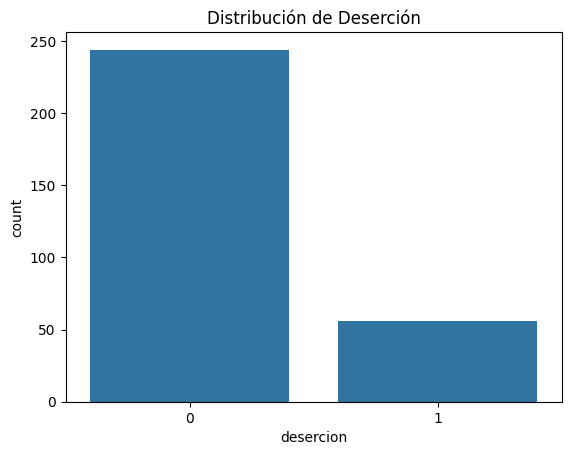

In [ ]:
sns.countplot(x="desercion", data=data)
plt.title("Distribución de Deserción")
plt.show()

Se observa la proporción de estudiantes que desertan frente a los que permanecen activos.

Esto permite identificar si el dataset está balanceado o presenta sesgos.

📌 Asistencia vs Deserción

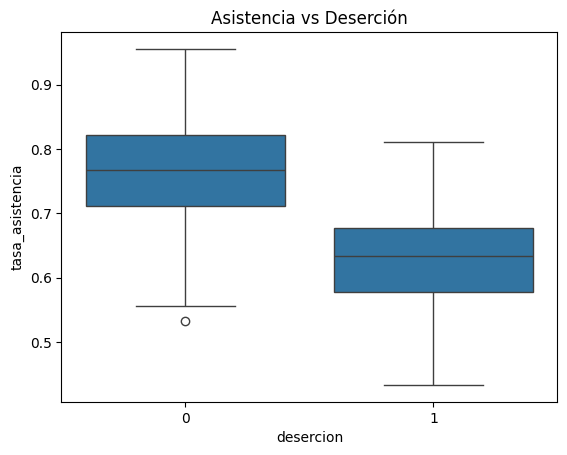

In [ ]:
sns.boxplot(x="desercion", y="tasa_asistencia", data=data)
plt.title("Asistencia vs Deserción")
plt.show()

Los estudiantes con menor asistencia presentan mayor probabilidad de deserción.

📌 Promedio vs Deserción

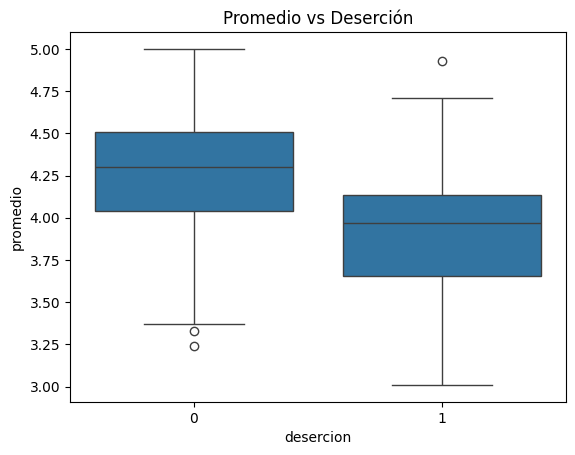

In [ ]:
sns.boxplot(x="desercion", y="promedio", data=data)
plt.title("Promedio vs Deserción")
plt.show()

Un menor rendimiento académico está asociado a mayor abandono.

📌 Uso de plataforma vs Deserción

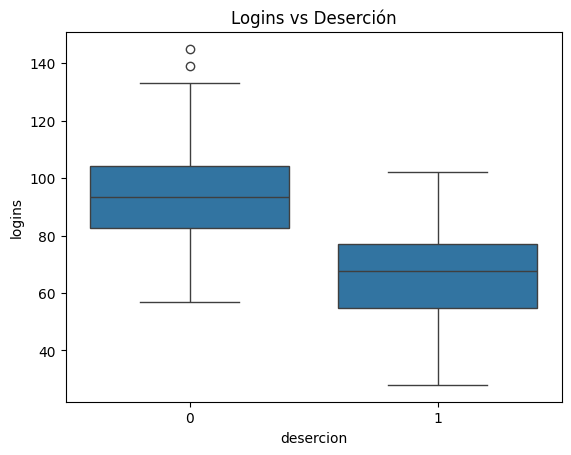

In [ ]:
sns.boxplot(x="desercion", y="logins", data=data)
plt.title("Logins vs Deserción")
plt.show()

Menor interacción con la plataforma puede indicar bajo compromiso del estudiante.

📌 Mapa de correlación

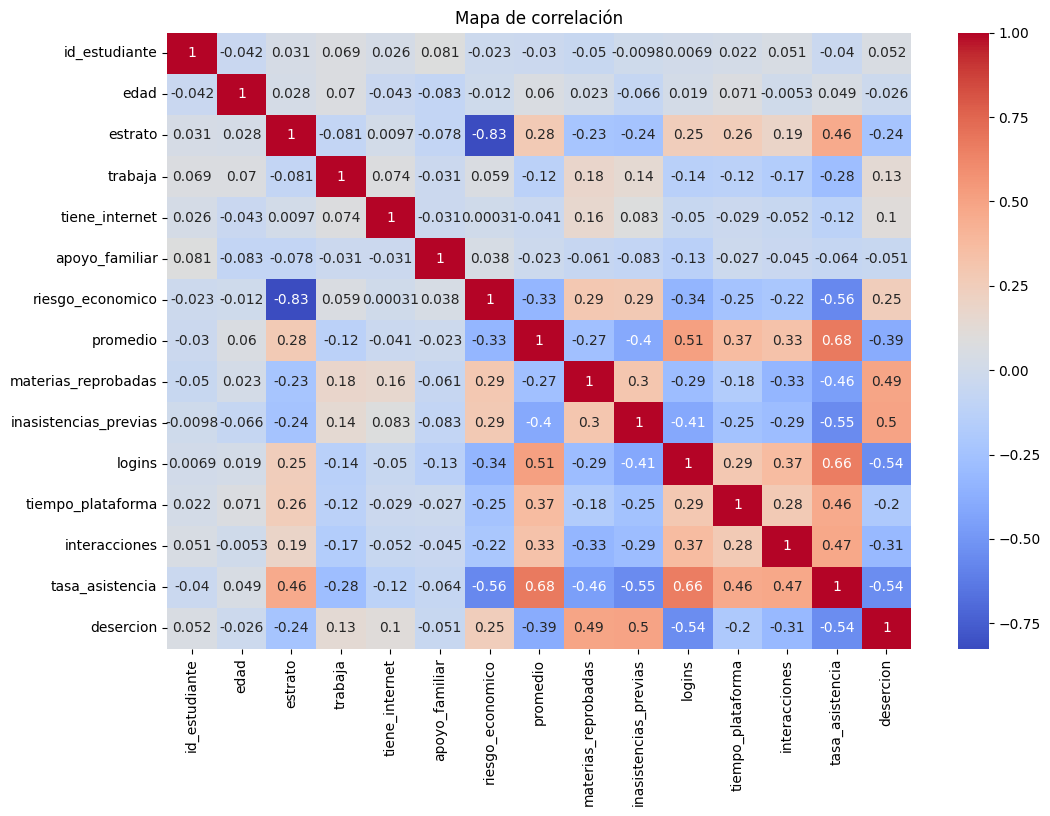

In [ ]:
# Seleccionar solo variables numéricas
data_num = data.select_dtypes(include=[np.number])

plt.figure(figsize=(12,8))
sns.heatmap(data_num.corr(), annot=True, cmap="coolwarm")
plt.title("Mapa de correlación")
plt.show()

Para el análisis de correlación se consideran únicamente variables numéricas,
ya que las variables categóricas no permiten calcular correlaciones directas.

## 🧩 PREPARACIÓN DE DATOS PARA MODELO

Se separan las variables predictoras (X) y la variable objetivo (y).

Se transforman variables categóricas mediante encoding.

In [ ]:
X = data.drop(["desercion","id_estudiante"], axis=1)
y = data["desercion"]

# One Hot Encoding
X = pd.get_dummies(X, drop_first=True)

X.head()

,edad,estrato,trabaja,tiene_internet,apoyo_familiar,riesgo_economico,promedio,materias_reprobadas,inasistencias_previas,logins,tiempo_plataforma,interacciones,tasa_asistencia,genero_M,ciudad_Bogotá,ciudad_Cali,ciudad_Medellín,educacion_padres_Secundaria,educacion_padres_Universitaria
0,22,4,1,0,2,0,3.56,2,6.0,99,9,35,0.644444,False,False,True,False,True,False
1,30,6,0,0,1,0,4.19,1,2.0,99,11,41,0.900000,True,True,False,False,True,False
2,26,2,1,0,2,1,3.52,1,10.0,86,7,44,0.611111,False,True,False,False,True,False
3,23,3,0,0,3,0,4.23,2,3.0,109,9,42,0.811111,True,False,False,True,False,True
4,22,1,0,0,4,1,4.28,2,7.0,45,6,27,0.655556,False,False,False,True,False,False


📌 Train-Test Split

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

## 🤖 Modelo Predictivo

Se utiliza un modelo de Regresión Logística para predecir la probabilidad de deserción.

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

## 📊 Evaluación del modelo

Se evalúa el desempeño del modelo utilizando:

- Matriz de confusión
- Classification report
- Curva ROC

📌 Matriz de confusión

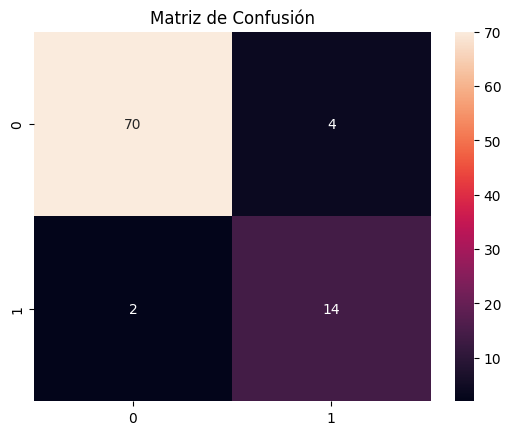

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt="d")
plt.title("Matriz de Confusión")
plt.show()

📌 Reporte de clasificación

In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.95      0.96        74
           1       0.78      0.88      0.82        16

    accuracy                           0.93        90
   macro avg       0.88      0.91      0.89        90
weighted avg       0.94      0.93      0.93        90



📌 Curva ROC

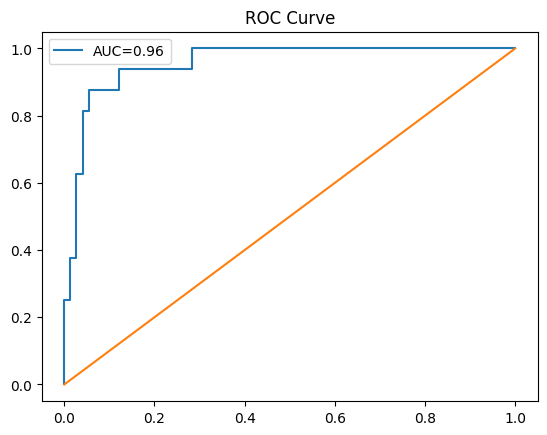

In [ ]:
y_prob = model.predict_proba(X_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"AUC={roc_auc:.2f}")
plt.plot([0,1],[0,1])
plt.legend()
plt.title("ROC Curve")
plt.show()

## 📈 Importancia de variables

Se analizan los coeficientes del modelo para identificar qué variables tienen mayor impacto en la deserción.

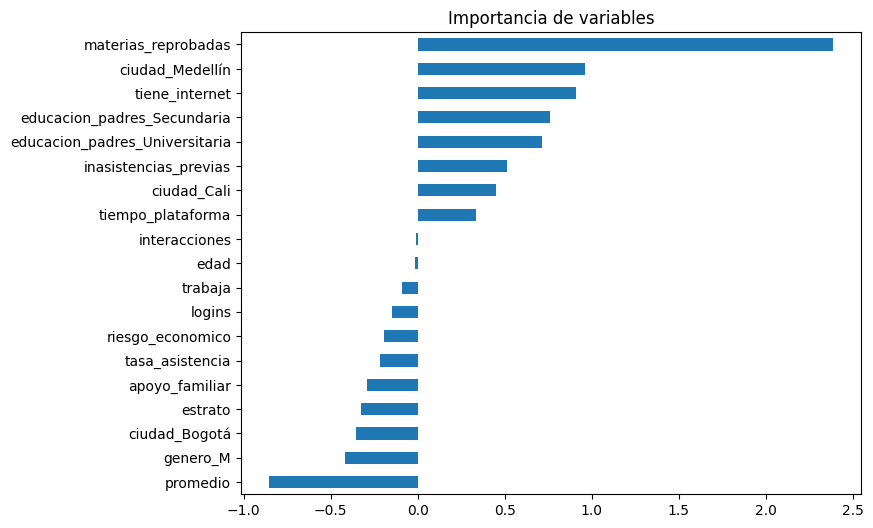

In [ ]:
coef = pd.Series(model.coef_[0], index=X.columns)

coef.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Importancia de variables")
plt.show()

## 💾 Exportación de datos

Se exporta el dataset final en formatos CSV y SQL para su uso en aplicaciones como dashboards o Streamlit.

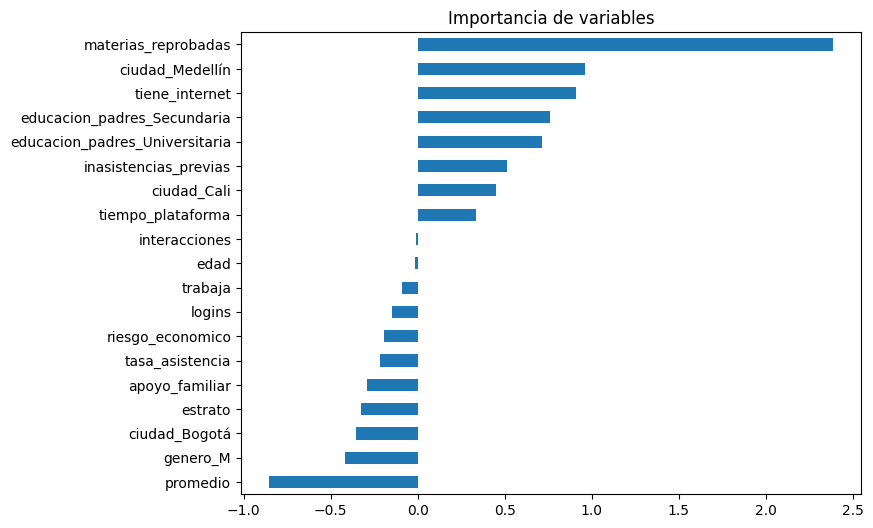

In [ ]:
coef = pd.Series(model.coef_[0], index=X.columns)

coef.sort_values().plot(kind="barh", figsize=(8,6))
plt.title("Importancia de variables")
plt.show()

## 💾 Exportación de datos

Se exporta el dataset final en formatos CSV y SQL para su uso en aplicaciones como dashboards o Streamlit.

In [ ]:
# CSV
data.to_csv("DATA_FINAL.csv", index=False, float_format="%.6f")

# SQL
import sqlite3

conn = sqlite3.connect("data_estudiantes.db")
data.to_sql("estudiantes", conn, if_exists="replace", index=False)
conn.close()

## 🧾Conclusiones

- La deserción estudiantil está fuertemente influenciada por:
  - La asistencia
  - El rendimiento académico
  - El nivel de interacción con la plataforma

- El modelo predictivo permite anticipar estudiantes en riesgo.

## 🚀 CTA

- Implementar alertas tempranas
- Diseñar estrategias de retención
- Monitorear continuamente el comportamiento estudiantil

In [ ]:
estudiantes.to_csv("TABLA_ESTUDIANTES.csv", index=False, encoding='utf-8-sig')

# 2. Exportar Tabla Asistencia
asistencia.to_csv("TABLA_ASISTENCIA.csv", index=False, encoding='utf-8-sig')

# 3. Exportar Tabla Académico
academico.to_csv("TABLA_ACADEMICO.csv", index=False, encoding='utf-8-sig')

# 4. Exportar Tabla Comportamiento
comportamiento.to_csv("TABLA_COMPORTAMIENTO.csv", index=False, encoding='utf-8-sig')

# 5. Exportar Tabla Data (Dataset Consolidado)
data.to_csv("TABLA_DATA_FINAL.csv", index=False, encoding='utf-8-sig')

print("¡Exportación completada! Los 5 archivos .csv han sido generados.")

¡Exportación completada! Los 5 archivos .csv han sido generados.
